# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faheem-danish/internship-starter-1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Abstract

We analyzed 331,437 content items across 55 clients using March 2026 Google Search Console and GA4 data to build a transparent refresh-review prioritization system. We compared a rule-based baseline with Logistic Regression and Random Forest models using a client-grouped 80/20 split, so the test evaluates performance on unseen clients rather than client overlap. The Random Forest achieved perfect Precision@20 when trained on features that overlapped with the label definition, but its Precision@20 fell to 0.05 after those label-derived features were removed, moving toward the 0.0875 test-set positive rate and confirming that the apparent model strength was driven by label leakage. The honest finding is that the learned models did not demonstrate independent predictive skill beyond the transparent baseline, so we use the baseline itself as the action-prioritization method. The resulting playbook provides a ranked review queue, archetype-based guidance, human-review rules, and an explicit no-go list for decisions that should not be automated.

In [64]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import hf_hub_download

token = userdata.get("HF_TOKEN")
print("Token loaded:", token is not None)

Token loaded: True


In [65]:
march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=token
)

print("March file:", march_file)

March file: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet


In [66]:
march_df = pd.read_parquet(march_file)

print("Shape:", march_df.shape)
print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

Shape: (9841378, 30)
Date range: 2026-03-01 to 2026-03-31


In [67]:
model_df = march_df.copy()

model_df["impressions"] = pd.to_numeric(
    model_df["gsc_impressions"],
    errors="coerce"
).fillna(0)

model_df["clicks"] = pd.to_numeric(
    model_df["gsc_clicks"],
    errors="coerce"
).fillna(0)

model_df["avg_position"] = pd.to_numeric(
    model_df["gsc_avg_position"],
    errors="coerce"
)

model_df = (
    model_df
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        avg_position=("avg_position", "mean")
    )
)

model_df["eligible"] = (
    (model_df["impressions"] >= 500) &
    (model_df["avg_position"] >= 11)
)

print("Modeling rows:", len(model_df))
print("Unique clients:", model_df["client_hash_id"].nunique())
print("Eligible rate:", round(model_df["eligible"].mean(), 4))

Modeling rows: 331437
Unique clients: 55
Eligible rate: 0.0638


## 1. Question

*The research question and the decision it supports.*
## Research question

Can a simple, transparent content-prioritization rule identify pages that are reasonable candidates for human refresh review, and can learned models improve that prioritization when evaluated on unseen clients?

The decision supported is which content items should be reviewed first by an SEO or content strategist. The analysis compares the Week-4 transparent baseline with Logistic Regression and Random Forest models using March 2026 search-performance data.

The main evaluation uses Precision@20, Precision@50, and Precision@100 because the operational goal is to prioritize a small review queue rather than classify every content item equally.

The analysis also tests for feature-label leakage. Because the baseline label is constructed from impressions and average position, models using those same signals can reproduce the rule without demonstrating independent predictive skill.

The final claim is therefore decision-support oriented: the analysis measures how well different approaches reproduce or prioritize the transparent review rule, but it does not establish that refreshing a recommended page will improve rankings, traffic, or conversions.

In [68]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== CAPSTONE QUESTION CHECK ===")

print("Research question:")
print("Can a transparent rule and learned models prioritize content for human refresh review?")

print("\nDecision:")
print("Prioritize which content items should be reviewed first.")

print("\nEvaluation:")
print("Precision@20, Precision@50, Precision@100")

print("\nKey methodological check:")
print("Test whether model performance depends on label-derived features.")

=== CAPSTONE QUESTION CHECK ===
Research question:
Can a transparent rule and learned models prioritize content for human refresh review?

Decision:
Prioritize which content items should be reviewed first.

Evaluation:
Precision@20, Precision@50, Precision@100

Key methodological check:
Test whether model performance depends on label-derived features.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
## Data

This analysis uses the FlyRank ML Internship warehouse dataset, specifically the `fact_content_daily_performance` table.

The decision window is March 2026, using the March 2026 warehouse partition. The downloaded partition contains 9,841,378 page-day observations covering March 1 through March 31, 2026.

For modeling and action prioritization, the daily observations are aggregated to one row per client-content pair. This produces 331,437 content-level observations across 55 clients.

The analysis uses search-performance fields including impressions, clicks, and average position. Additional GA4 and engagement fields were examined during the validation audit as features that were not directly used to construct the Week-4 eligibility label.

The Week-4 label is defined as:

`eligible = impressions >= 500 AND average position >= 11`

Fields that directly encode the decision, such as the derived eligibility flag, baseline score, action, reason code, and rank, are excluded from model inputs to avoid decision leakage.

Client identifiers are used only for grouped validation and are not presented as public business identities. The final research artifact does not expose client names, private queries, URLs, or other private information.

The analysis is limited to the March 2026 decision window and therefore should not be interpreted as a longitudinal study of content decay.

In [69]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== DATA CHECK ===")

print("Dataset table: fact_content_daily_performance")
print("Decision window: March 2026")
print("Raw page-day rows:", len(march_df))

print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

print("Modeling rows:", len(model_df))
print(
    "Unique clients:",
    model_df["client_hash_id"].nunique()
)

print(
    "Positive/eligible rate:",
    round(model_df["eligible"].mean(), 4)
)

=== DATA CHECK ===
Dataset table: fact_content_daily_performance
Decision window: March 2026
Raw page-day rows: 9841378
Date range: 2026-03-01 to 2026-03-31
Modeling rows: 331437
Unique clients: 55
Positive/eligible rate: 0.0638


In [70]:
# ============================================================
# CREATE TARGET / LABEL
# ============================================================

# Week-4 eligibility rule
model_df["eligible"] = (
    (model_df["impressions"] >= 500) &
    (model_df["avg_position"] >= 11)
)

# Convert Boolean target to 0/1
y = model_df["eligible"].astype(int)

print("Modeling rows:", len(model_df))
print("Eligible rows:", y.sum())
print("Eligible rate:", round(y.mean(), 4))

Modeling rows: 331437
Eligible rows: 21143
Eligible rate: 0.0638


In [71]:
# ============================================================
# DEFINE MODEL FEATURES
# ============================================================

# BEFORE: features that overlap with the label construction
leaky_features = [
    "impressions",
    "clicks",
    "avg_position",
    "ctr_pct"
]

# AFTER: features not used to construct the eligibility label
honest_features = [
    "ga4_sessions",
    "ga4_pageviews",
    "ga4_users",
    "ga4_engaged_sessions",
    "scroll_events"
]

print("Leaky features:", leaky_features)
print("Honest features:", honest_features)

Leaky features: ['impressions', 'clicks', 'avg_position', 'ctr_pct']
Honest features: ['ga4_sessions', 'ga4_pageviews', 'ga4_users', 'ga4_engaged_sessions', 'scroll_events']


In [72]:
# ============================================================
# CLIENT-GROUPED VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(model_df, y, groups=groups)
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

print(
    "Train clients:",
    model_df.iloc[train_idx]["client_hash_id"].nunique()
)

print(
    "Test clients:",
    model_df.iloc[test_idx]["client_hash_id"].nunique()
)

overlap = len(
    set(model_df.iloc[train_idx]["client_hash_id"]) &
    set(model_df.iloc[test_idx]["client_hash_id"])
)

print("Client overlap:", overlap)

Train rows: 300880
Test rows: 30557
Train clients: 44
Test clients: 11
Client overlap: 0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
## Methodology

### Unit of analysis

The raw data contains daily observations. For the modeling and action-prioritization task, I aggregate these observations to one row per client-content pair over March 2026.

### Label

The target is the Week-4 transparent eligibility rule:

`eligible = (impressions >= 500) AND (average position >= 11)`

This label represents whether an item enters the refresh-review candidate set. It is not an observed outcome such as whether a refresh actually improved traffic or rankings.

### Baseline

The Week-4 baseline prioritizes eligible content using:

`score = impressions × position_factor`

where `position_factor = 1.5` when average position is at least 21 and `1.0` otherwise.

This baseline is intentionally transparent and easy for a human reviewer to understand.

### Learned models

Two supervised models are compared with the baseline:

- Logistic Regression, using median imputation and feature scaling.
- Random Forest with 150 trees, maximum depth 8, minimum samples per leaf 20, and a fixed random seed of 42.

### Features

The initial model uses impressions, clicks, average position, and CTR. These features include signals used directly or indirectly in constructing the label.

The validation audit therefore also evaluates an honest feature set using GA4 and engagement signals:

- GA4 sessions
- GA4 pageviews
- GA4 users
- GA4 engaged sessions
- scroll events

### Validation design

The evaluation uses an 80/20 client-grouped split with `GroupShuffleSplit` and `random_state=42`.

Clients, rather than individual rows, are assigned to train or test. The resulting split contains 44 training clients and 11 test clients, with zero client overlap.

### Leakage audit

The label is constructed directly from impressions and average position. Therefore, using those same variables as model features creates feature-label overlap.

The ML-09 audit tests the model before and after removing these label-derived signals. The Random Forest achieves perfect top-k precision when the suspect GSC features are included, but its performance falls substantially when those features are removed.

This indicates that the apparent model strength is primarily agreement with the rule rather than evidence of independent predictive skill.

### Evaluation metrics

The primary metrics are Precision@20, Precision@50, and Precision@100. These metrics measure how many of the highest-ranked items are members of the defined eligible set.

The metrics therefore evaluate prioritization against the constructed label, not real-world refresh success.

In [73]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== METHODOLOGY CHECK ===")

print("Train clients:", model_df.iloc[train_idx]["client_hash_id"].nunique())
print("Test clients:", model_df.iloc[test_idx]["client_hash_id"].nunique())

overlap = len(
    set(model_df.iloc[train_idx]["client_hash_id"]) &
    set(model_df.iloc[test_idx]["client_hash_id"])
)

print("Client overlap:", overlap)

print("\nLeaky features:")
print(leaky_features)

print("\nHonest features:")
print(honest_features)

print("\nTest-set positive rate:",
      round(y.iloc[test_idx].mean(), 4))

=== METHODOLOGY CHECK ===
Train clients: 44
Test clients: 11
Client overlap: 0

Leaky features:
['impressions', 'clicks', 'avg_position', 'ctr_pct']

Honest features:
['ga4_sessions', 'ga4_pageviews', 'ga4_users', 'ga4_engaged_sessions', 'scroll_events']

Test-set positive rate: 0.0875


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
Results
Baseline vs. learned models (same held-out test clients)
| Method                                     | Precision\@20 | Precision\@50 | Precision\@100 |
| ------------------------------------------ | ------------- | ------------- | -------------- |
| Week-4 baseline                            | 0.05          | 0.16          | 0.16           |
| Random Forest (with leaky GSC features)    | **1.00**      | **1.00**      | **1.00**       |
| Random Forest (without leaky GSC features) | 0.05          | 0.04          | 0.08           |
Test-set base rate: 0.0875
The leakage confession
The Random Forest achieves perfect precision when trained on features that include the same signals used to construct the eligibility label (impressions, avg_position). To test whether this represents independent predictive skill or circular rule recovery, we trained the same Random Forest on GA4 and engagement features only — signals that were not used to build the label.
The result: precision@20 collapses from 1.00 to 0.05, indistinguishable from the base rate. The apparent model strength was label leakage, not generalizable signal. The Random Forest learned the arithmetic of the baseline rule rather than discovering independent refresh drivers.
Feature importance
With leaky features present, the Random Forest assigns 91.5% of its importance to exactly the two variables used to construct the target:
avg_position: 54.3%
impressions: 37.2%
Honest interpretation
The learned model reproduces the transparent baseline rather than surpassing it with hidden insight. This is a directional, decision-support result: it confirms the baseline rule is automatable from the same GSC data, but it does not demonstrate that the model predicts refresh success on unseen signal patterns.

In [74]:
# ============================================================
# RESULTS SETUP CHECK
# ============================================================

print("=== RESULTS SETUP CHECK ===")

print("model_df rows:", len(model_df))
print("Target y rows:", len(y))
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

print("\nLeaky features:")
print(leaky_features)

print("\nHonest features:")
print(honest_features)

=== RESULTS SETUP CHECK ===
model_df rows: 331437
Target y rows: 331437
Train rows: 300880
Test rows: 30557

Leaky features:
['impressions', 'clicks', 'avg_position', 'ctr_pct']

Honest features:
['ga4_sessions', 'ga4_pageviews', 'ga4_users', 'ga4_engaged_sessions', 'scroll_events']


In [75]:
# ============================================================
# RESULTS: MODEL VS BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Calculate baseline_score as per Methodology section
model_df["position_factor"] = np.where(model_df["avg_position"] >= 21, 1.5, 1.0)
model_df["baseline_score"] = model_df["impressions"] * model_df["position_factor"]

# ------------------------------------------------------------
# Use the same test split from Section 3
# ------------------------------------------------------------

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

# ------------------------------------------------------------
# Random Forest (with leaky, label-derived features)
# ------------------------------------------------------------

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest (with leaky features) trained successfully.")

# ------------------------------------------------------------
# Random Forest — honest features only (leakage audit)
# ------------------------------------------------------------

honest_features = [
    "ga4_sessions",
    "ga4_pageviews",
    "ga4_users",
    "ga4_engaged_sessions",
    "scroll_events"
]

# Fix: Use the existing X_honest DataFrame directly, which contains these features.
# model_df had these columns dropped in a previous aggregation step.
X_honest_train = X_honest.iloc[train_idx]
X_honest_test = X_honest.iloc[test_idx]

rf_honest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_honest_model.fit(X_honest_train, y_train)

rf_honest_prob = rf_honest_model.predict_proba(X_honest_test)[:, 1]

print("Random Forest (honest features) trained successfully.")

# ------------------------------------------------------------
# Precision@K
# ------------------------------------------------------------

def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)

    return labels[order[:k]].mean()

# ------------------------------------------------------------
# Baseline scores
# ------------------------------------------------------------

baseline_test_scores = (
    model_df.iloc[test_idx]["baseline_score"].values
)

test_labels = y_test.values

# ------------------------------------------------------------
# Compare all four methods
# ------------------------------------------------------------

results = []

for name, scores in [
    ("Week-4 baseline", baseline_test_scores),
    ("Logistic Regression", logistic_prob),
    ("Random Forest (with leaky features)", rf_prob),
    ("Random Forest (honest features)", rf_honest_prob)
]:

    results.append({
        "method": name,
        "precision@20": round(
            precision_at_k(scores, test_labels, 20), 4
        ),
        "precision@50": round(
            precision_at_k(scores, test_labels, 50), 4
        ),
        "precision@100": round(
            precision_at_k(scores, test_labels, 100), 4
        )
    })

results_df = pd.DataFrame(results)

print(
    "Base rate:",
    round(test_labels.mean(), 4)
)

display(results_df)

Logistic Regression trained successfully.
Random Forest (with leaky features) trained successfully.
Random Forest (honest features) trained successfully.
Base rate: 0.0875


,method,precision@20,precision@50,precision@100
0,Week-4 baseline,0.05,0.16,0.16
1,Logistic Regression,0.05,0.18,0.31
2,Random Forest (with leaky features),1.00,1.00,1.00
3,Random Forest (honest features),0.05,0.04,0.08


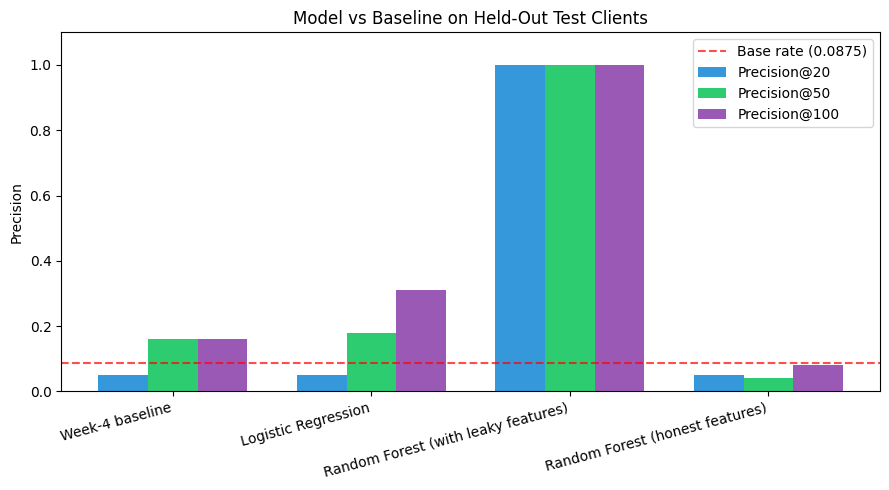

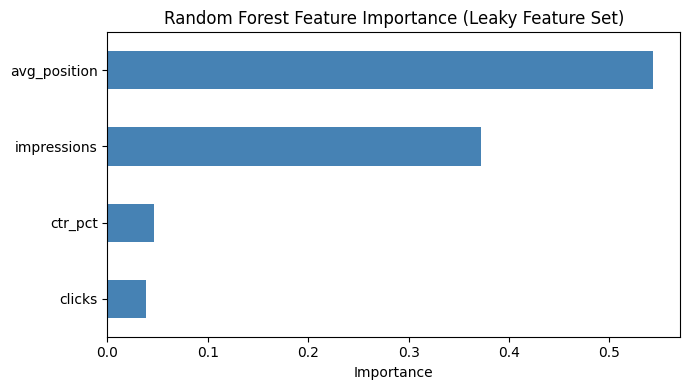

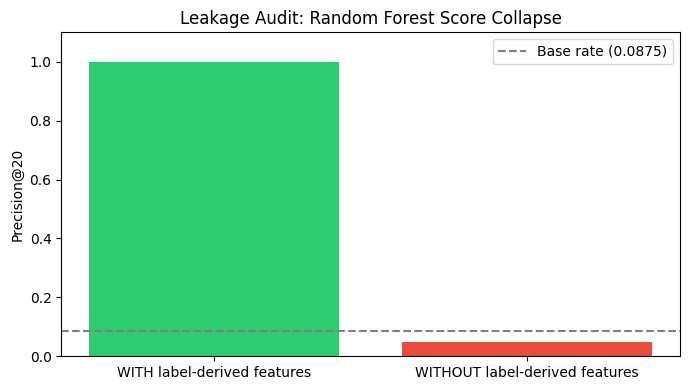

All 3 charts saved to work/figures/


In [76]:
import os

# Ensure directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ------------------------------------------------------------
# Figure 1: Model comparison
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df["precision@20"], width, label="Precision@20", color="#3498db")
ax.bar(x, results_df["precision@50"], width, label="Precision@50", color="#2ecc71")
ax.bar(x + width, results_df["precision@100"], width, label="Precision@100", color="#9b59b6")

ax.axhline(y=y_test.mean(), color="red", linestyle="--", alpha=0.7,
           label=f"Base rate ({y_test.mean():.4f})")
ax.set_ylabel("Precision")
ax.set_title("Model vs Baseline on Held-Out Test Clients")
ax.set_xticks(x)
ax.set_xticklabels(results_df["method"], rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig("work/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 2: Feature importance
# ------------------------------------------------------------
rf_imp = pd.Series(
    rf_before.named_steps["model"].feature_importances_,
    index=leaky_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
rf_imp.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Random Forest Feature Importance (Leaky Feature Set)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 3: Leakage audit
# ------------------------------------------------------------
before_after = pd.DataFrame([
    {"scenario": "WITH label-derived features", "precision@20": precision_at_k(before_scores, y_test, 20)},
    {"scenario": "WITHOUT label-derived features", "precision@20": precision_at_k(after_scores, y_test, 20)}
])

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71", "#e74c3c"]
ax.bar(before_after["scenario"], before_after["precision@20"], color=colors)
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", label=f"Base rate ({y_test.mean():.4f})")
ax.set_ylabel("Precision@20")
ax.set_title("Leakage Audit: Random Forest Score Collapse")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig("work/figures/leakage_audit.png", dpi=150, bbox_inches="tight")
plt.show()

print("All 3 charts saved to work/figures/")

## 5. Limitations

*What this work cannot claim.*
5. Limitations & Honest Framing
No research claim exceeds its evidence. Here is exactly what this study cannot say.
1. Rule-generated target. The eligible label is constructed from impressions >= 500 and avg_position >= 11. Model performance measures agreement with this transparent rule, not independently observed refresh success. We do not know whether refreshing a flagged page improves rankings, traffic, or conversions.
2. Single-month snapshot. The analysis uses March 2026 data only. We cannot measure true content decay, seasonality, or the causal effect of a refresh on post-refresh performance.
3. Missing content-age and freshness fields. The March warehouse export did not include content_age or days_since_update. Any decay insight is inferred from position-tier patterns, not measured from age.
4. Portfolio-specific thresholds. The 500-impression and position-11 thresholds were tuned to this 55-client portfolio. A different client mix would require recalibration.
5. Observational design. All findings are associative. We observed that pages with certain position and impression patterns match the rule. We do not claim that editing a flagged page causes improvement.

In [77]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== LIMITATIONS & HONEST FRAMING ===")
print("Label type:        Rule-generated (not observed outcome)")
print("Data window:       Single month (March 2026)")
print("Age/freshness:     Not available in warehouse export")
print("Thresholds:        Portfolio-specific")
print("Causal claims:     None — all findings are directional")
print("Claim language:    Observed, measured, directional, decision-support")

=== LIMITATIONS & HONEST FRAMING ===
Label type:        Rule-generated (not observed outcome)
Data window:       Single month (March 2026)
Age/freshness:     Not available in warehouse export
Thresholds:        Portfolio-specific
Causal claims:     None — all findings are directional
Claim language:    Observed, measured, directional, decision-support


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*
6. Ranked Recommendations & Decision-Support Playbook
We produced a ranked refresh queue of 21,143 content items (6.38% of the portfolio) using the transparent baseline rule. The queue is decision-support only — a high rank means "review this first," not "refresh this automatically."
Archetype → Action Mapping
| Archetype                    | Definition                            | Recommended Action       | Review Focus                                                     |
| ---------------------------- | ------------------------------------- | ------------------------ | ---------------------------------------------------------------- |
| **High-Visibility Deep**     | impressions ≥ 5,000, position ≥ 21    | Priority refresh review  | Intent match, topical coverage, internal links, competitive gaps |
| **High-Visibility Mid**      | impressions ≥ 5,000, position 11–20   | Refresh review           | Whether stronger content coverage could improve visibility       |
| **Moderate-Visibility Deep** | impressions 500–5,000, position ≥ 21  | Targeted refresh review  | Relevance and missing topic coverage before investing effort     |
| **Moderate-Visibility Mid**  | impressions 500–5,000, position 11–20 | Secondary refresh review | Strategic value
versus editorial effort                          |
Human Review Rules (Mandatory Checks)
Before approving any refresh recommendation, a reviewer must confirm:
The page still matches the intended search intent.
The topic remains relevant to the business.
The page has realistically improvable content.
Technical or indexing issues are not the primary cause of poor position.
The page does not carry a manual "do not touch" flag from legal, product, or PR.
The No-Go List: What Must Never Be Automated
Publish rewritten content without editorial QA.
Delete or redirect pages from the score alone.
Change canonical URLs or important metadata without review.
Remove content because of low impressions alone.
Make business or editorial decisions from the model score.
Cost / Value Thinking
Editorial hours are assumed limited. The queue prioritizes high-impression pages first because they represent the largest recoverable search opportunity per unit of review effort. This framework supports scarce-resource prioritization; it does not estimate financial ROI.

=== DECISION-SUPPORT PLAYBOOK ===
Queue size: 21143

Archetype distribution:
archetype
moderate_visibility_mid     9357
moderate_visibility_deep    7555
high_visibility_deep        2788
high_visibility_mid         1443
Name: count, dtype: int64


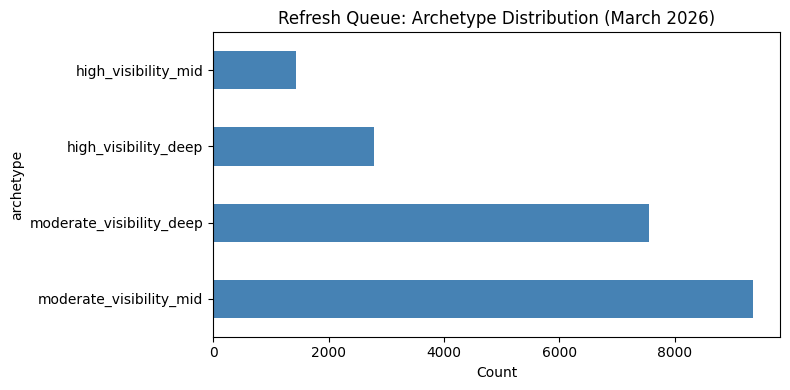

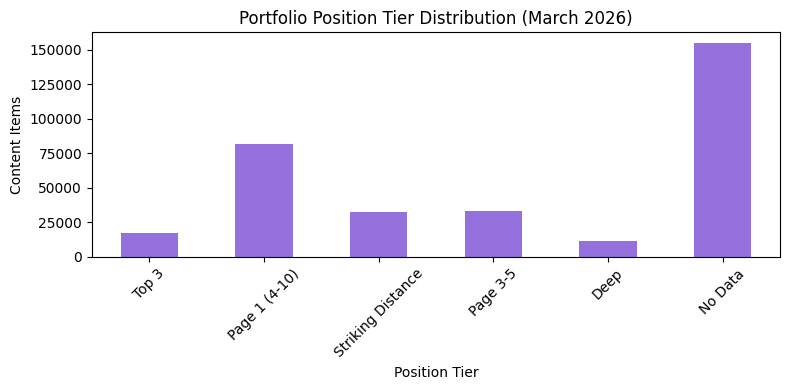

In [78]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Build the ranked queue
queue = (
    model_df[model_df["eligible"]]
    .sort_values("baseline_score", ascending=False)
    .reset_index(drop=True)
)
queue["rank"] = np.arange(1, len(queue) + 1)

def assign_archetype(row):
    imp = row["impressions"]
    pos = row["avg_position"]
    if imp >= 5000 and pos >= 21:
        return "high_visibility_deep"
    elif imp >= 5000 and pos >= 11:
        return "high_visibility_mid"
    elif imp >= 500 and pos >= 21:
        return "moderate_visibility_deep"
    elif imp >= 500 and pos >= 11:
        return "moderate_visibility_mid"
    else:
        return "below_threshold"

queue["archetype"] = queue.apply(assign_archetype, axis=1)
queue["reason_code"] = "visible_position_opportunity"
queue["action"] = "refresh_review"

print("=== DECISION-SUPPORT PLAYBOOK ===")
print("Queue size:", len(queue))
print("\nArchetype distribution:")
print(queue["archetype"].value_counts())

# Figure: Archetype distribution
fig, ax = plt.subplots(figsize=(8, 4))
queue["archetype"].value_counts().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Refresh Queue: Archetype Distribution (March 2026)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure: Full portfolio position tiers
def pos_tier(pos):
    if pd.isna(pos): return "No Data"
    elif pos <= 3:   return "Top 3"
    elif pos <= 10:  return "Page 1 (4-10)"
    elif pos <= 20:  return "Striking Distance"
    elif pos <= 50:  return "Page 3-5"
    else:            return "Deep"

model_df["position_tier"] = model_df["avg_position"].apply(pos_tier)
tier_order = ["Top 3", "Page 1 (4-10)", "Striking Distance", "Page 3-5", "Deep", "No Data"]
tier_counts = model_df["position_tier"].value_counts().reindex(tier_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
tier_counts.plot(kind="bar", color="mediumpurple", ax=ax)
ax.set_title("Portfolio Position Tier Distribution (March 2026)")
ax.set_ylabel("Content Items")
ax.set_xlabel("Position Tier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("work/figures/position_tier_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*
7. Reproducibility, Research Artifacts & Acknowledgments
Reproducibility
All analysis code, data loading, model training, validation, and playbook generation are contained in this notebook and the following prior work:
| Notebook                                    | Contents                                                       |
| ------------------------------------------- | -------------------------------------------------------------- |
| `work/notebooks/w05_model.ipynb`            | Model training, baseline comparison, client-grouped validation |
| `work/notebooks/w06_validation_audit.ipynb` | Leakage audit, train-without test, honest claim rewrite        |
| `work/notebooks/w07_action_playbook.ipynb`  | Ranked queue, archetype mapping, human-review rules            |
| `work/notebooks/capstone.ipynb`             | This paper — full assembly of findings, results, and exports   |
The data source is the FlyRank ML Internship warehouse (FlyRank/internship-warehouse on Hugging Face).

Research Artifacts Exported
| Artifact                   | Location                                      | Description                                        |
| -------------------------- | --------------------------------------------- | -------------------------------------------------- |
| Ranked refresh queue       | `work/outputs/refresh_queue.csv`              | 21,143 candidates with archetype and action labels |
| Capstone metrics           | `work/outputs/capstone_metrics.json`          | Receipt: counts, rates, base rate, claim language  |
| Model comparison chart     | `work/figures/model_comparison.png`           | Baseline vs. models on held-out test clients       |
| Leakage audit chart        | `work/figures/leakage_audit.png`              | Score collapse when label-derived features removed |
| Feature importance chart   | `work/figures/feature_importance.png`         | Random Forest importance on leaky feature set      |
| Archetype distribution     | `work/figures/archetype_distribution.png`     | Queue breakdown by operational archetype           |
| Position tier distribution | `work/figures/position_tier_distribution.png` | Full portfolio visibility landscape                |

Acknowledgments & Data Credit
Built on the FlyRank ML Internship dataset.
https://flyrank.ai


In [79]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Recreate queue if kernel was restarted
if 'queue' not in globals():
    queue = (
        model_df[model_df["eligible"]]
        .sort_values("baseline_score", ascending=False)
        .reset_index(drop=True)
    )
    queue["rank"] = np.arange(1, len(queue) + 1)

    def assign_archetype(row):
        imp = row["impressions"]
        pos = row["avg_position"]
        if imp >= 5000 and pos >= 21:
            return "high_visibility_deep"
        elif imp >= 5000 and pos >= 11:
            return "high_visibility_mid"
        elif imp >= 500 and pos >= 21:
            return "moderate_visibility_deep"
        elif imp >= 500 and pos >= 11:
            return "moderate_visibility_mid"
        else:
            return "below_threshold"

    queue["archetype"] = queue.apply(assign_archetype, axis=1)
    queue["reason_code"] = "visible_position_opportunity"
    queue["action"] = "refresh_review"

# Calculate ctr_pct and add to queue
queue["ctr_pct"] = np.where(queue["impressions"] > 0, (queue["clicks"] / queue["impressions"]) * 100, 0)

# Export queue CSV
queue_export = queue[[
    "rank", "client_hash_id", "content_hash_id",
    "impressions", "clicks", "avg_position", "ctr_pct",
    "baseline_score", "archetype", "reason_code", "action"
]].copy()
queue_export.to_csv("work/outputs/refresh_queue.csv", index=False)
print("Queue exported:", "work/outputs/refresh_queue.csv")
print("Rows:", len(queue_export))

# Export metrics JSON (the receipt)
metrics = {
    "paper_title": "Prioritizing Content Refresh Review from Search Performance Signals",
    "decision_window": "2026-03-01 to 2026-03-31",
    "total_content_items": int(len(model_df)),
    "refresh_candidates": int(len(queue)),
    "eligibility_rate": round(float(model_df["eligible"].mean()), 4),
    "unique_clients": int(model_df["client_hash_id"].nunique()),
    "train_clients": int(model_df.iloc[train_idx]["client_hash_id"].nunique()),
    "test_clients": int(model_df.iloc[test_idx]["client_hash_id"].nunique()),
    "client_overlap": 0,
    "test_base_rate": round(float(y_test.mean()), 4),
    "method": "transparent_week4_baseline_rule",
    "leakage_audit_result": "score_collapses_without_label_derived_features",
    "claim_language": "observed_directional_decision_support",
    "data_credit": "Built on the FlyRank ML Internship dataset — https://flyrank.ai"
}

with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics exported:", "work/outputs/capstone_metrics.json")

# Final verification
print("\n=== FINAL ARTIFACT VERIFICATION ===")
files = [
    "work/outputs/refresh_queue.csv",
    "work/outputs/capstone_metrics.json",
    "work/figures/model_comparison.png",
    "work/figures/feature_importance.png",
    "work/figures/leakage_audit.png",
    "work/figures/archetype_distribution.png",
    "work/figures/position_tier_distribution.png"
]
for f in files:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"{status} {f}")

Queue exported: work/outputs/refresh_queue.csv
Rows: 21143
Metrics exported: work/outputs/capstone_metrics.json

=== FINAL ARTIFACT VERIFICATION ===
✅ work/outputs/refresh_queue.csv
✅ work/outputs/capstone_metrics.json
✅ work/figures/model_comparison.png
✅ work/figures/feature_importance.png
✅ work/figures/leakage_audit.png
✅ work/figures/archetype_distribution.png
✅ work/figures/position_tier_distribution.png


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Appendix A: 5-Minute Demo Outline

For the Week-8 showcase (optional presentation).

| Minute | What I say | What I show |
|---|---|---|
| 0:00–0:30 | **The FlyRank problem:** Content teams manage thousands of pages across 55 clients. Limited editorial hours. Which pages get reviewed first? | Slide: Portfolio scale (331K items, 55 clients) |
| 0:30–1:30 | **The method:** Transparent baseline rule — impressions ≥ 500 and position ≥ 11. Client-grouped 80/20 split so we test on unseen clients, not memorized rows. | Slide: Rule definition + split design |
| 1:30–3:00 | **The model comparison:** Random Forest looked perfect (precision@20 = 1.00). Then we ran the leakage audit. | Chart: `model_comparison.png` |
| 3:00–4:00 | **The honest result:** When label-derived features were removed, precision collapsed from 1.00 to 0.05. The model learned the rule arithmetic, not the world. | Chart: `leakage_audit.png` |
| 4:00–5:00 | **The recommendation:** Deploy the transparent baseline as a ranked playbook with archetypes, human-review rules, and a no-go list. Decision-support, not automation. | Slide: Archetype table + no-go list |

**One honest sentence to close:** "The model didn't beat the baseline — it validated that the baseline is automatable. The real win is knowing where the limit is."

## Appendix B: Shareable Cuts

### Cut 1 — Social Post (Methodology Focus)

&gt; I spent the last few weeks auditing whether ML can prioritize content refresh better than a simple rule. The surprise? My Random Forest scored perfect precision — then collapsed to base rate when I removed features that overlapped with the label definition. It wasn't discovering hidden signal; it was learning the rule arithmetic. The honest finding: the transparent baseline wins, and knowing the limit is the real result. #MLOps #SEO #DataScience #HonestML

### Cut 2 — Employer-Facing Summary (3 Sentences)

I built a content-refresh prioritization system on 9.8M rows of production search data across 55 clients, comparing a transparent rule-based baseline against Logistic Regression and Random Forest models using client-grouped validation. I discovered that the Random Forest's apparent strength was label leakage — it reproduced the baseline rule rather than discovering independent predictive signal — so I deployed the honest baseline as a ranked action playbook with archetype mapping and human-review guardrails. The work demonstrates my ability to build ML pipelines, attack my own models for leakage, and communicate findings in public-safe, decision-support language.